# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin

In [4]:

def decimate_overlap_save(x, h, M, N_fft):
    """
    Filtra e decima um sinal usando Overlap-and-Save.
    
    Parâmetros:
    x     : Sinal de entrada (1D array)
    h     : Resposta ao impulso do filtro passa-baixas antialiasing (1D array)
    M     : Fator de decimação (inteiro)
    N_fft : Tamanho da FFT (deve ser >= len(h))
    """
    P = len(h)
    if N_fft < P:
        raise ValueError("O tamanho da FFT deve ser maior ou igual ao tamanho do filtro.")
        
    step = N_fft - P + 1 # Tamanho do salto (bloco de amostras novas)
    
    # 1. FFT do filtro (calculada apenas uma vez)
    H = np.fft.fft(h, N_fft)
    
    # 2. Preenchimento (padding) inicial com P-1 zeros no sinal de entrada
    x_padded = np.pad(x, (P - 1, 0), mode='constant')
    
    y_out = []
    global_valid_idx = 0 # Rastreador do índice global para manter a subamostragem correta
    
    # 3. Processamento por blocos
    for i in range(0, len(x_padded) - N_fft + 1, step):
        # Extrai o bloco atual
        x_block = x_padded[i : i + N_fft]
        
        # Convolução rápida via FFT/IFFT
        X_block = np.fft.fft(x_block)
        Y_block = X_block * H
        y_block = np.real(np.fft.ifft(Y_block))
        
        # Descarta as primeiras P-1 amostras (lixo da convolução circular)
        y_valid = y_block[P - 1:]
        
        # 4. Decimação do bloco válido
        # Precisamos garantir que estamos pegando as amostras corretas considerando a continuidade
        start_idx = (M - (global_valid_idx % M)) % M
        y_decimated = y_valid[start_idx :: M]
        
        y_out.extend(y_decimated)
        global_valid_idx += len(y_valid)
        
    return np.array(y_out)


def interpolate_overlap_save(x, h, L, N_fft):
    """
    Interpola e filtra um sinal usando Overlap-and-Save.
    
    Parâmetros:
    x     : Sinal de entrada (1D array)
    h     : Resposta ao impulso do filtro passa-baixas anti-imagem (1D array)
    L     : Fator de interpolação (inteiro)
    N_fft : Tamanho da FFT (deve ser >= len(h))
    """
    P = len(h)
    if N_fft < P:
        raise ValueError("O tamanho da FFT deve ser maior ou igual ao tamanho do filtro.")
        
    # 1. Sobreamostragem: Inserir L-1 zeros entre as amostras
    x_up = np.zeros(len(x) * L)
    x_up[::L] = x
    
    step = N_fft - P + 1
    
    # 2. FFT do filtro (multiplicado por L para compensar a perda de energia dos zeros)
    H = np.fft.fft(h * L, N_fft)
    
    # 3. Preenchimento inicial com P-1 zeros
    x_padded = np.pad(x_up, (P - 1, 0), mode='constant')
    
    y_out = []
    
    # 4. Processamento por blocos sobre o sinal já expandido
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        
        # Convolução rápida via FFT/IFFT
        X_block = np.fft.fft(x_block)
        Y_block = X_block * H
        y_block = np.real(np.fft.ifft(Y_block))
        
        # Descarta as primeiras P-1 amostras
        y_valid = y_block[P - 1:]
        y_out.extend(y_valid)
        
    return np.array(y_out)

In [6]:
def decimate_overlap_save(x, h, M, N_fft):
    P = len(h)
    step = N_fft - P + 1
    H = np.fft.fft(h, N_fft)
    
    # CALCULANDO O PADDING FINAL: Garante que a "cauda" do sinal caiba no último bloco
    pad_end = N_fft - (len(x) % step) 
    x_padded = np.pad(x, (P - 1, pad_end), mode='constant')
    
    y_out = []
    global_valid_idx = 0
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        y_block = np.real(np.fft.ifft(np.fft.fft(x_block) * H))
        y_valid = y_block[P - 1:]
        
        start_idx = (M - (global_valid_idx % M)) % M
        y_decimated = y_valid[start_idx :: M]
        y_out.extend(y_decimated)
        global_valid_idx += len(y_valid)
        
    # Trunca o excesso para o tamanho exato de uma decimação
    expected_len = int(np.ceil(len(x) / M))
    return np.array(y_out)[:expected_len]

def interpolate_overlap_save(x, h, L, N_fft):
    P = len(h)
    x_up = np.zeros(len(x) * L)
    x_up[::L] = x
    step = N_fft - P + 1
    H = np.fft.fft(h * L, N_fft) 
    
    # CALCULANDO O PADDING FINAL
    pad_end = N_fft - (len(x_up) % step)
    x_padded = np.pad(x_up, (P - 1, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        y_block = np.real(np.fft.ifft(np.fft.fft(x_block) * H))
        y_valid = y_block[P - 1:]
        y_out.extend(y_valid)
        
    # Trunca o excesso para o tamanho exato de uma interpolação
    expected_len = len(x) * L
    return np.array(y_out)[:expected_len]

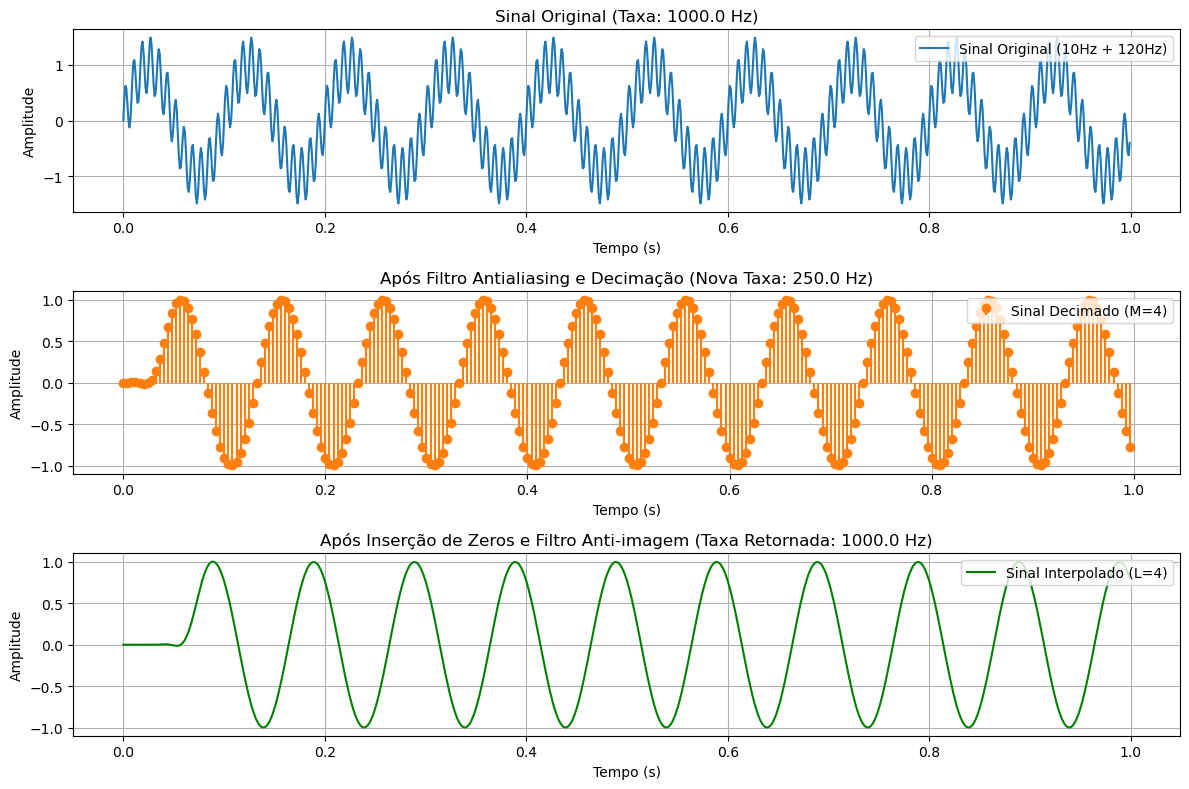

In [7]:
fs = 1000.0          # Frequência de amostragem original (Hz)
t = np.arange(0, 1.0, 1/fs) # 1 segundo de sinal

# Sinal: 10 Hz (desejado) + 120 Hz (ruído/alta frequência)
x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Parâmetros de Multitaxa
M = 4 # Fator de decimação
L = 4 # Fator de interpolação
N_fft = 256 # Tamanho da FFT (Bloco)

# Projeto do Filtro FIR Passa-Baixas (Comprimento P = 65)
# Frequência de Nyquist = fs/2 = 500 Hz. Corte em 50 Hz para eliminar os 120 Hz.
cutoff_hz = 50.0
h_fir = firwin(65, cutoff_hz, fs=fs)

# ==========================================
# 3. Execução do Processamento
# ==========================================
# A) Decimação
y_decimado = decimate_overlap_save(x, h_fir, M, N_fft)
t_decimado = np.arange(0, len(y_decimado)) * (M / fs)

# B) Interpolação (reconstruindo o sinal decimado)
y_interpolado = interpolate_overlap_save(y_decimado, h_fir, L, N_fft)
# Ajuste de tamanho para o plot (O OLA pode gerar algumas amostras a mais no final do último bloco)
y_interpolado = y_interpolado[:len(x)] 
# Trunca o vetor de tempo para ter o mesmo tamanho do sinal interpolado
t_interpolado = t[:len(y_interpolado)]
# ==========================================
# 4. Visualização
# ==========================================
plt.figure(figsize=(12, 8))

# Sinal Original
plt.subplot(3, 1, 1)
plt.plot(t, x, label='Sinal Original (10Hz + 120Hz)')
plt.title(f'Sinal Original (Taxa: {fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

# Sinal Decimado
plt.subplot(3, 1, 2)
plt.stem(t_decimado, y_decimado, basefmt=" ", linefmt='C1-', markerfmt='C1o', label=f'Sinal Decimado (M={M})')
plt.title(f'Após Filtro Antialiasing e Decimação (Nova Taxa: {fs/M} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

# Sinal Interpolado
plt.subplot(3, 1, 3)
plt.plot(t_interpolado, y_interpolado, color='green', label=f'Sinal Interpolado (L={L})')
plt.title(f'Após Inserção de Zeros e Filtro Anti-imagem (Taxa Retornada: {fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

plt.tight_layout()
plt.show()